In [4]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

In [10]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
train_dir = "/content/drive/My Drive/FruitinAmazon/train/"
test_dir = "/content/drive/My Drive/FruitinAmazon/test/"
img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2
seed = 123
epochs = 10

TASK 1: Data Inspection
No corrupted images found.


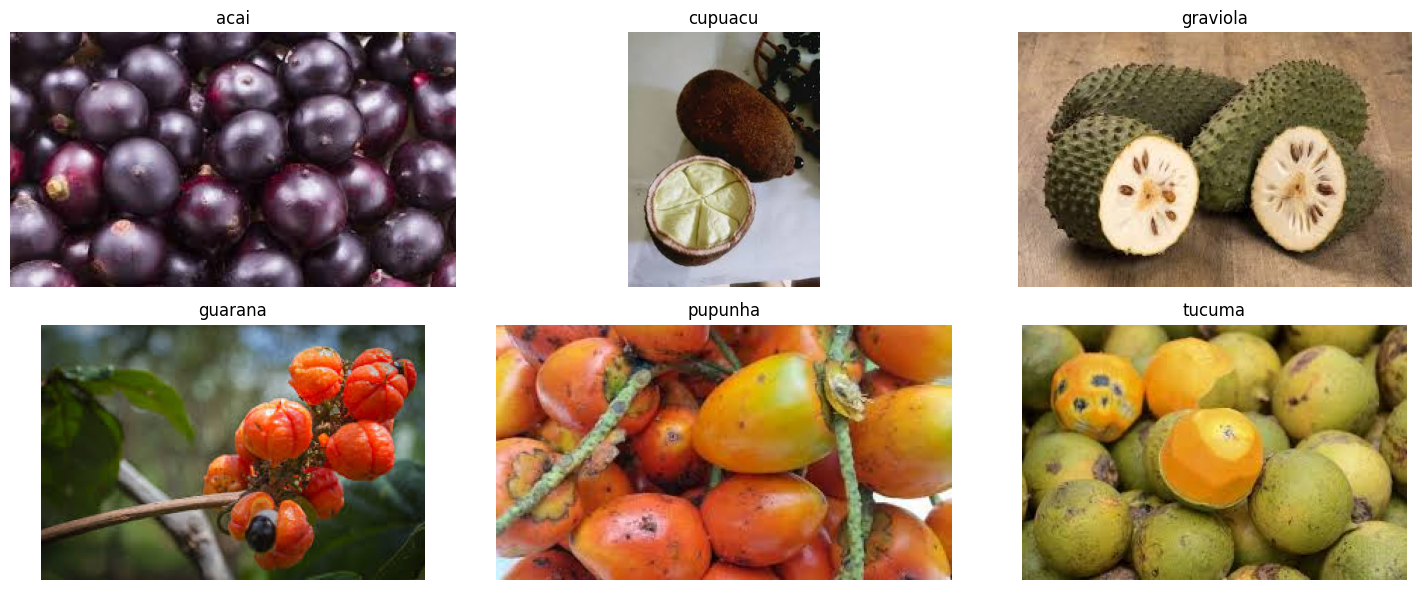

Observed 6 classes. Each folder contains images of that fruit.


In [14]:
import random
import os # Ensure os is imported, though it was already implicitly available

def check_corrupted_images(directory):
    """Check and remove corrupted images in the directory tree."""
    if not os.path.exists(directory):
        print(f"Error: Directory not found at {directory}")
        return

    corrupted_count = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                file_path = os.path.join(root, file)
                try:
                    with Image.open(file_path) as img:
                        img.verify()
                except (IOError, SyntaxError, OSError):
                    print(f"Removed corrupted image: {file_path}")
                    os.remove(file_path)
                    corrupted_count += 1
    if corrupted_count == 0:
        print("No corrupted images found.")
    else:
        print(f"Removed {corrupted_count} corrupted images.")

def visualize_one_per_class(train_dir):
    """Display one image from each class in a grid."""
    if not os.path.exists(train_dir):
        print(f"Error: Training directory not found at {train_dir}. Please ensure the dataset is correctly located.")
        return

    classes = [d for d in os.listdir(train_dir)
               if os.path.isdir(os.path.join(train_dir, d))]
    classes.sort()
    num_classes = len(classes)

    if num_classes == 0:
        print(f"No classes found in the directory: {train_dir}. Please check if the directory contains subfolders representing classes.")
        return

    fig, axes = plt.subplots(2, (num_classes + 1) // 2, figsize=(15, 6))
    axes = axes.flatten()

    for i, class_name in enumerate(classes):
        class_path = os.path.join(train_dir, class_name)
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            img_path = os.path.join(class_path, random.choice(images))
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(class_name)
            axes[i].axis('off')

    # Hide unused subplots
    for j in range(num_classes, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    print(f"Observed {num_classes} classes. Each folder contains images of that fruit.")

# Run Task 1
print("=" * 50)
print("TASK 1: Data Inspection")
print("=" * 50)
check_corrupted_images(train_dir)
visualize_one_per_class(train_dir)


In [15]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=seed
)

# Load test dataset (no shuffling, no validation split)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


In [16]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")

# Normalize pixel values from [0,255] to [0,1]
rescale = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Optional: Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [17]:
# Infer number of classes from training directory
class_names = sorted(
    [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
)
num_classes = len(class_names)

model = keras.Sequential([
    # Convolutional Block 1
    layers.Conv2D(32, (3,3), padding='same', strides=1, activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Convolutional Block 2
    layers.Conv2D(32, (3,3), padding='same', strides=1, activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Flatten and Fully Connected Layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 610ms/step - accuracy: 0.1806 - loss: 2.0742 - val_accuracy: 0.5000 - val_loss: 1.4431
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 511ms/step - accuracy: 0.3333 - loss: 1.6076 - val_accuracy: 0.6667 - val_loss: 1.5479
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 419ms/step - accuracy: 0.5139 - loss: 1.4769 - val_accuracy: 0.7222 - val_loss: 1.3859
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5000 - loss: 1.2437 - val_accuracy: 0.6667 - val_loss: 1.1634
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 911ms/step - accuracy: 0.6528 - loss: 1.0059 - val_accuracy: 0.6667 - val_loss: 0.9108
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 890ms/step - accuracy: 0.7778 - loss: 0.7514 - val_accuracy: 0.6667 - val_loss: 1.2579
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 800ms/step - accuracy: 0.8333 - loss: 0.6073 - val_accuracy: 0.7778 - val_loss: 0.7948
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8889 - loss: 0.4135 - val_accuracy: 0.8889 - val_loss: 0.482

In [20]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix (optional)
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.6333 - loss: 0.7929
Test Loss: 0.7929
Test Accuracy: 0.6333

Classification Report:
              precision    recall  f1-score   support

        acai       0.60      0.60      0.60         5
     cupuacu       0.45      1.00      0.62         5
    graviola       1.00      0.80      0.89         5
     guarana       0.75      0.60      0.67         5
     pupunha       0.67      0.80      0.73         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.63        30
   macro avg       0.58      0.63      0.58        30
weighted avg       0.58      0.63      0.58        30


Confusion Matrix:
[[3 2 0 0 0 0]
 [0 5 0 0 0 0]
 [0 1 4 0 0 0]
 [1 1 0 3 0 0]
 [0 0 0 1 4 0]
 [1 2 0 0 2 0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


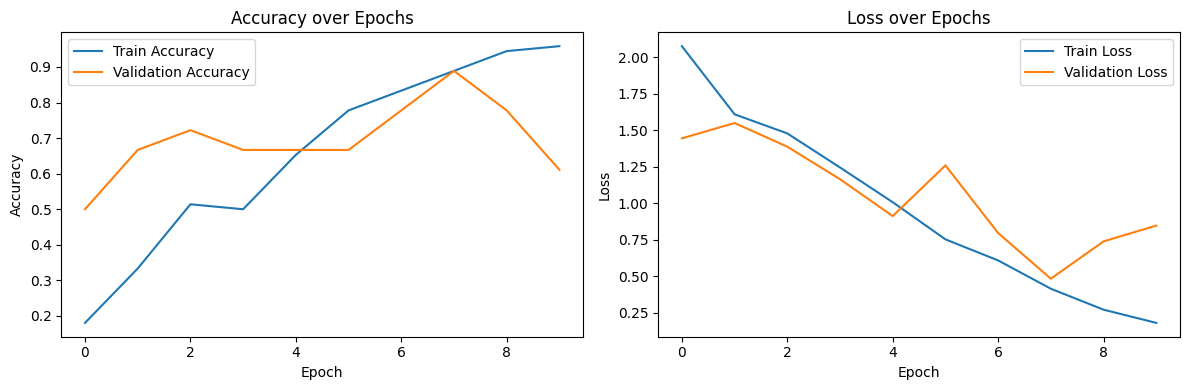

In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.tight_layout()
plt.show()

In [22]:
model.save('fruit_classifier.h5')
print("Model saved as 'fruit_classifier.h5'")

# Optional: Load and test
loaded_model = keras.models.load_model('fruit_classifier.h5')
print("Model loaded successfully.")

Model saved as 'fruit_classifier.h5'
Model loaded successfully.
